# Model Comparison: C4.5 vs. Sklearn Classifiers

This notebook compares the custom C4.5 decision tree against six standard classifiers on the same training/test data used in the validation pipeline.

**Models compared:**
1. **C4.5** (custom implementation — locked best params from validation pipeline)
2. **CART** (`DecisionTreeClassifier`)
3. **Random Forest** (`RandomForestClassifier`)
4. **Logistic Regression** (`LogisticRegression`)
5. **SVM (RBF)** (`SVC` with RBF kernel)
6. **kNN** (`KNeighborsClassifier`)
7. **Naive Bayes** (`GaussianNB`)

**Evaluation conditions (same 4 as the validation pipeline):**
- TRTR · No Threshold
- TRTR · Thresholded
- TRSTR · No Threshold
- TRSTR · Thresholded

## 1. Imports & Constants

In [1]:
import os, sys, warnings
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from scipy.stats import norm
from sklearn.utils import resample
from sklearn.metrics import (
    fbeta_score, f1_score, recall_score, precision_score,
    accuracy_score, roc_auc_score, mean_squared_error, make_scorer
)

sys.path.append(str(Path().resolve().parent))
from src.C45DecisionTree import C45DecisionTree

warnings.filterwarnings('ignore')

# ── Plot settings ──
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

# ── Paths ──
ROOT_DIR = Path().resolve().parent
PROCESSED_DATASET_DIR = ROOT_DIR / 'datasets' / 'processed'
OUTPUTS_DIR = ROOT_DIR / 'outputs'
LOGS_OUTPUTS = OUTPUTS_DIR / 'logs_and_metrics'
os.makedirs(LOGS_OUTPUTS, exist_ok=True)

# ── Feature definitions (identical to validation pipeline) ──
EPSILON = 1e-9
SEED = 42
NUMBER_PROCESSING = ['NC', 'DM']
ARITHMETIC_FLUENCY = ['NS', 'ADD', 'SUB', 'CA']
FEATURE_COLUMNS = NUMBER_PROCESSING + ARITHMETIC_FLUENCY
DERIVED_FEATURES = ['NP', 'SN', 'AF', 'BC', 'AS', 'PF']

INCOMPLETE_FLAGS = [
    'NC_incomplete', 'DM_incomplete', 'NS_incomplete',
    'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete'
]

FUNA_DB_RAW_FEATURES = FEATURE_COLUMNS + INCOMPLETE_FLAGS
FUNA_DB_DIAGNOSTIC_FEATURES = FUNA_DB_RAW_FEATURES + DERIVED_FEATURES

FUNA_DB_DOMAIN_MAPPING: Dict[str, str] = {
    'NC':  'Number Comparison',
    'DM':  'Digit-Dot Matching',
    'NP':  'Overall Processing Efficiency',
    'SN':  'Symbolic vs. Non-Symbolic Processing Difference',
    'NS':  'Number Series',
    'ADD': 'Single-Digit Addition',
    'SUB': 'Single-Digit Subtraction',
    'CA':  'Multi-Digit Addition and Subtraction',
    'AF':  'Overall Arithmetic Fluency',
    'BC':  'Basic vs. Complex Arithmetic Contrast',
    'AS':  'Addition vs. Subtraction Asymmetry',
    'PF':  'Processing-Fluency Integration',
}

# Threshold search range (same as validation pipeline)
THRESHOLDS = np.arange(0.35, 0.76, 0.05).round(2)

print('Imports and constants loaded.')
print(f'Features ({len(FUNA_DB_DIAGNOSTIC_FEATURES)}): {FUNA_DB_DIAGNOSTIC_FEATURES}')

Imports and constants loaded.
Features (18): ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'NP', 'SN', 'AF', 'BC', 'AS', 'PF']


## 2. Data Loading

Load the same 70/15/15 splits used in the validation pipeline.

In [2]:
def split_xy(df: pd.DataFrame, label_col: str = 'Label'):
    X = df[FUNA_DB_DIAGNOSTIC_FEATURES]
    y = df[label_col]
    return X, y

print('Loading 70/15/15 Datasets...')

r_train = pd.read_csv(PROCESSED_DATASET_DIR / 'train.csv')
s_train = pd.read_csv(PROCESSED_DATASET_DIR / 's_train.csv')
val_df  = pd.read_csv(PROCESSED_DATASET_DIR / 'val.csv')
test_df = pd.read_csv(PROCESSED_DATASET_DIR / 'test.csv')

train_trtr  = r_train.copy()                                      # TRTR: real only
train_trstr = pd.concat([r_train, s_train], ignore_index=True)     # TRSTR: real + synthetic

print(f'TRTR  Train shape (Real 70%):       {train_trtr.shape}')
print(f'TRSTR Train shape (Real + Synth):   {train_trstr.shape}')
print(f'Validation shape (Real 15%):        {val_df.shape}')
print(f'Test shape (Real 15%):              {test_df.shape}')

X_train_trtr,  y_train_trtr  = split_xy(train_trtr)
X_train_trstr, y_train_trstr = split_xy(train_trstr)
X_val,  y_val  = split_xy(val_df)
X_test, y_test = split_xy(test_df)

N_REAL_TRSTR = len(r_train)

print(f'\nTest class distribution: {dict(y_test.value_counts())}')

Loading 70/15/15 Datasets...
TRTR  Train shape (Real 70%):       (221, 19)
TRSTR Train shape (Real + Synth):   (286, 19)
Validation shape (Real 15%):        (47, 19)
Test shape (Real 15%):              (48, 19)

Test class distribution: {0: np.int64(31), 1: np.int64(17)}


## 3. Model Registry & Evaluation Helpers

### C4.5 best parameters
Locked from the validation pipeline Phase 5 outputs.

### Sklearn models
Light `GridSearchCV` (5-fold StratifiedKFold, F2-optimized) on the training set to keep the comparison fair with the tuned C4.5.

### Threshold search
For thresholded conditions, thresholds are optimized on `val.csv` (never the test set), same strategy as C4.5.

In [3]:
# ── C4.5 locked best params from validation pipeline ──
C45_BEST_PARAMS = {
    ('TRTR',  'no_threshold'): {'conf_fact': 0.5,  'min_samples_leaf': 10, 'max_depth': 15},
    ('TRTR',  'thresholded'):  {'conf_fact': 0.45, 'min_samples_leaf': 10, 'max_depth': 15},
    ('TRSTR', 'no_threshold'): {'conf_fact': 0.1,  'min_samples_leaf': 15, 'max_depth': 15},
    ('TRSTR', 'thresholded'):  {'conf_fact': 0.1,  'min_samples_leaf': 15, 'max_depth': 15},
}

C45_BEST_THRESHOLDS = {
    ('TRTR',  'thresholded'): 0.35,
    ('TRSTR', 'thresholded'): 0.40,
}

# ── F2 scorer for GridSearchCV ──
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

# ── Sklearn model definitions with light grids ──
SKLEARN_MODELS = {
    'CART': {
        'pipeline': Pipeline([
            ('clf', DecisionTreeClassifier(random_state=SEED))
        ]),
        'param_grid': {
            'clf__max_depth': [5, 8, 10, 15, None],
            'clf__min_samples_leaf': [5, 10, 15, 20],
            'clf__criterion': ['gini', 'entropy'],
        },
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('clf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
        ]),
        'param_grid': {
            'clf__n_estimators': [50, 100, 200],
            'clf__max_depth': [5, 10, 15, None],
            'clf__min_samples_leaf': [5, 10, 15],
        },
    },
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(random_state=SEED, max_iter=2000))
        ]),
        'param_grid': {
            'clf__C': [0.01, 0.1, 1.0, 10.0],
            'clf__penalty': ['l2'],
        },
    },
    'SVM (RBF)': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', probability=True, random_state=SEED))
        ]),
        'param_grid': {
            'clf__C': [0.1, 1.0, 10.0],
            'clf__gamma': ['scale', 'auto', 0.01, 0.1],
        },
    },
    'kNN': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'param_grid': {
            'clf__n_neighbors': [3, 5, 7, 9, 11],
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan'],
        },
    },
    'Naive Bayes': {
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', GaussianNB())
        ]),
        'param_grid': {
            'clf__var_smoothing': [1e-11, 1e-9, 1e-7, 1e-5, 1e-3],
        },
    },
}

print(f'Registered {len(SKLEARN_MODELS)} sklearn models + C4.5 = {len(SKLEARN_MODELS) + 1} total.')
for name in SKLEARN_MODELS:
    grid_size = 1
    for v in SKLEARN_MODELS[name]['param_grid'].values():
        grid_size *= len(v)
    print(f'  {name}: {grid_size} candidates')

Registered 6 sklearn models + C4.5 = 7 total.
  CART: 40 candidates
  Random Forest: 36 candidates
  Logistic Regression: 4 candidates
  SVM (RBF): 12 candidates
  kNN: 20 candidates
  Naive Bayes: 5 candidates


In [4]:
# ── Metric computation (identical to validation pipeline) ──
def safe_roc_auc(y_true, probs) -> float:
    y_numeric = np.asarray(y_true).astype(int)
    if len(np.unique(y_numeric)) < 2:
        return np.nan
    return roc_auc_score(y_numeric, probs)

def compute_metrics(y_true, preds, probs=None) -> dict:
    y_numeric = np.asarray(y_true).astype(int)
    metrics = {
        'Recall':    recall_score(y_numeric, preds, zero_division=0),
        'Precision': precision_score(y_numeric, preds, zero_division=0),
        'F1':        f1_score(y_numeric, preds, zero_division=0),
        'F2':        fbeta_score(y_numeric, preds, beta=2, zero_division=0),
        'Accuracy':  accuracy_score(y_numeric, preds),
    }
    if probs is not None:
        metrics['AUC-ROC'] = safe_roc_auc(y_numeric, probs)
        metrics['RMSE']    = np.sqrt(mean_squared_error(y_numeric, probs))
    # Lowercase aliases for bootstrap CI compatibility
    metrics['recall']    = metrics['Recall']
    metrics['precision'] = metrics['Precision']
    metrics['f1']        = metrics['F1']
    metrics['f2']        = metrics['F2']
    metrics['accuracy']  = metrics['Accuracy']
    if probs is not None:
        metrics['auc']   = metrics['AUC-ROC']
        metrics['rmse']  = metrics['RMSE']
    return metrics

METRIC_NAMES = ['Recall', 'Precision', 'F1', 'F2', 'Accuracy', 'AUC-ROC', 'RMSE']

# ── Helper: find best threshold on validation set ──
def find_best_threshold(probs_val, y_val, thresholds=THRESHOLDS):
    """Select threshold maximizing F2 on validation set."""
    best_th, best_f2 = 0.5, -1
    for th in thresholds:
        preds = (np.asarray(probs_val) >= th).astype(int)
        f2 = fbeta_score(np.asarray(y_val).astype(int), preds, beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_th = f2, th
    return best_th

# ── C4.5 helpers (identical to validation pipeline) ──
def c45_get_preds(tree, X):
    return [int(pred) for pred in tree.predict(X)]

def c45_get_probs(tree, X):
    return tree.predict_proba(X, positive_class=1)

def probs_to_preds(probs, threshold):
    return [1 if p >= threshold else 0 for p in probs]

print('Evaluation helpers loaded.')
# -- Shared constants --
MODEL_ORDER = ['C4.5', 'CART', 'Random Forest', 'Logistic Regression', 'SVM (RBF)', 'kNN', 'Naive Bayes']

CONDITION_LABELS = {
    ('TRTR',  'no_threshold'): 'TRTR — No Threshold',
    ('TRTR',  'thresholded'):  'TRTR — Thresholded',
    ('TRSTR', 'no_threshold'): 'TRSTR — No Threshold',
    ('TRSTR', 'thresholded'):  'TRSTR — Thresholded',
}

# -- Wilson score confidence interval (exact for proportions) --
def wilson_ci(y_true, y_pred, metric='recall', alpha=0.05):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    if metric == 'recall':
        n = np.sum(y_true == 1)
        count = np.sum((y_true == 1) & (y_pred == 1))
    elif metric == 'precision':
        n = np.sum(y_pred == 1)
        count = np.sum((y_true == 1) & (y_pred == 1))
    else:
        return (0.0, 0.0)

    if n == 0:
        return (0.0, 0.0)

    p = count / n
    z = norm.ppf(1 - alpha / 2)
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    spread = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom

    return center - spread, center + spread

# -- Bootstrap confidence interval --
def get_bootstrap_ci(y_true, y_pred, y_prob, metric_name, n_bootstraps=1000, alpha=0.05):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    n = len(y_true)
    stats = []

    for _ in range(n_bootstraps):
        idx = resample(np.arange(n))
        m = compute_metrics(y_true[idx], y_pred[idx], y_prob[idx])
        stats.append(m[metric_name])

    lower = np.percentile(stats, 100 * (alpha / 2))
    upper = np.percentile(stats, 100 * (1 - alpha / 2))
    return lower, upper

# Mapping from display metric names to bootstrap keys
METRIC_TO_BOOTSTRAP_KEY = {
    'Recall': 'recall', 'Precision': 'precision',
    'F1': 'f1', 'F2': 'f2', 'Accuracy': 'accuracy',
    'AUC-ROC': 'auc', 'RMSE': 'rmse',
}

print(f'Model order: {MODEL_ORDER}')
print('CI helpers loaded (Wilson + Bootstrap).')

Evaluation helpers loaded.
Model order: ['C4.5', 'CART', 'Random Forest', 'Logistic Regression', 'SVM (RBF)', 'kNN', 'Naive Bayes']
CI helpers loaded (Wilson + Bootstrap).


## 4. Evaluate All Models Across 4 Conditions

For each of `{TRTR, TRSTR} × {no_threshold, thresholded}`:
1. **C4.5**: train with locked params, evaluate on test set.
2. **Sklearn models**: `GridSearchCV` on training set, evaluate best estimator on test set.
3. **Thresholded**: optimize threshold on `val.csv`, then apply to test set.

In [5]:
CONDITIONS = {
    ('TRTR', 'no_threshold'):  {'X_train': X_train_trtr,  'y_train': y_train_trtr,  'threshold': None},
    ('TRTR', 'thresholded'):   {'X_train': X_train_trtr,  'y_train': y_train_trtr,  'threshold': 'optimize'},
    ('TRSTR', 'no_threshold'): {'X_train': X_train_trstr, 'y_train': y_train_trstr, 'threshold': None},
    ('TRSTR', 'thresholded'):  {'X_train': X_train_trstr, 'y_train': y_train_trstr, 'threshold': 'optimize'},
}

all_results = {}     # (condition_key) -> {model_name -> metrics_dict}
all_ci_results = {}  # (condition_key) -> {model_name -> {metric -> (lower, upper, ci_type)}}
best_sklearn_params = {}  # (condition_key, model_name) -> best_params

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_BOOTSTRAPS = 1000

for cond_key, cfg in CONDITIONS.items():
    label, mode = cond_key
    print(f'\n{"=" * 70}')
    print(f'  Condition: {label} | {mode.upper()}')
    print(f'{"=" * 70}')

    X_tr = cfg['X_train']
    y_tr = cfg['y_train']
    is_thresholded = (mode == 'thresholded')

    condition_results = {}
    condition_cis = {}

    # ==============================
    # A. C4.5
    # ==============================
    c45_params = C45_BEST_PARAMS[cond_key]
    tree = C45DecisionTree(**c45_params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
    tree.fit(X_tr, y_tr, raw_features=FUNA_DB_RAW_FEATURES)

    test_probs_c45 = c45_get_probs(tree, X_test)
    if is_thresholded:
        c45_th = C45_BEST_THRESHOLDS[cond_key]
        test_preds_c45 = probs_to_preds(test_probs_c45, c45_th)
        print(f'  C4.5: params={c45_params}, threshold={c45_th:.2f}')
    else:
        test_preds_c45 = c45_get_preds(tree, X_test)
        print(f'  C4.5: params={c45_params}')

    condition_results['C4.5'] = compute_metrics(y_test, test_preds_c45, test_probs_c45)

    # Confidence intervals for C4.5
    print(f'    Computing CIs...', end=' ', flush=True)
    ci_c45 = {}
    ci_c45['Recall']    = (*wilson_ci(y_test, test_preds_c45, 'recall'),    'Wilson')
    ci_c45['Precision'] = (*wilson_ci(y_test, test_preds_c45, 'precision'), 'Wilson')
    for metric, bkey in [('F1','f1'), ('F2','f2'), ('Accuracy','accuracy'), ('AUC-ROC','auc'), ('RMSE','rmse')]:
        lo, hi = get_bootstrap_ci(y_test, test_preds_c45, test_probs_c45, bkey, N_BOOTSTRAPS)
        ci_c45[metric] = (lo, hi, 'Bootstrap')
    condition_cis['C4.5'] = ci_c45
    m = condition_results['C4.5']
    print(f'Recall={m["Recall"]:.4f} [{ci_c45["Recall"][0]:.4f}, {ci_c45["Recall"][1]:.4f}], '
          f'F2={m["F2"]:.4f} [{ci_c45["F2"][0]:.4f}, {ci_c45["F2"][1]:.4f}]')

    # ==============================
    # B. Sklearn models
    # ==============================
    for model_name, model_cfg in SKLEARN_MODELS.items():
        print(f'  {model_name}: GridSearchCV...', end=' ')

        gs = GridSearchCV(
            estimator=model_cfg['pipeline'],
            param_grid=model_cfg['param_grid'],
            scoring=f2_scorer,
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        gs.fit(X_tr, y_tr)
        best_est = gs.best_estimator_

        best_sklearn_params[(cond_key, model_name)] = gs.best_params_
        print(f'best={gs.best_params_}')

        # Get probabilities
        if hasattr(best_est, 'predict_proba'):
            test_probs = best_est.predict_proba(X_test)[:, 1]
            val_probs  = best_est.predict_proba(X_val)[:, 1]
        else:
            test_probs = best_est.decision_function(X_test)
            val_probs  = best_est.decision_function(X_val)

        if is_thresholded:
            best_th = find_best_threshold(val_probs, y_val)
            test_preds = (np.asarray(test_probs) >= best_th).astype(int)
            print(f'    -> threshold={best_th:.2f}')
        else:
            test_preds = best_est.predict(X_test)

        condition_results[model_name] = compute_metrics(y_test, test_preds, test_probs)

        # Confidence intervals
        print(f'    Computing CIs...', end=' ', flush=True)
        ci_model = {}
        ci_model['Recall']    = (*wilson_ci(y_test, test_preds, 'recall'),    'Wilson')
        ci_model['Precision'] = (*wilson_ci(y_test, test_preds, 'precision'), 'Wilson')
        for metric, bkey in [('F1','f1'), ('F2','f2'), ('Accuracy','accuracy'), ('AUC-ROC','auc'), ('RMSE','rmse')]:
            lo, hi = get_bootstrap_ci(y_test, test_preds, test_probs, bkey, N_BOOTSTRAPS)
            ci_model[metric] = (lo, hi, 'Bootstrap')
        condition_cis[model_name] = ci_model
        m = condition_results[model_name]
        print(f'Recall={m["Recall"]:.4f} [{ci_model["Recall"][0]:.4f}, {ci_model["Recall"][1]:.4f}], '
              f'F2={m["F2"]:.4f} [{ci_model["F2"][0]:.4f}, {ci_model["F2"][1]:.4f}]')

    all_results[cond_key] = condition_results
    all_ci_results[cond_key] = condition_cis

print('\n' + '=' * 70)
print('All conditions evaluated with confidence intervals.')
print('=' * 70)


  Condition: TRTR | NO_THRESHOLD
  C4.5: params={'conf_fact': 0.5, 'min_samples_leaf': 10, 'max_depth': 15}
    Computing CIs... Recall=0.8235 [0.5897, 0.9381], F2=0.7955 [0.6000, 0.9328]
  CART: GridSearchCV... best={'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10}
    Computing CIs... Recall=0.8824 [0.6566, 0.9671], F2=0.8333 [0.6667, 0.9460]
  Random Forest: GridSearchCV... 

/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thr

best={'clf__max_depth': 5, 'clf__min_samples_leaf': 15, 'clf__n_estimators': 50}
    Computing CIs... Recall=0.6471 [0.4130, 0.8269], F2=0.6707 [0.4412, 0.8571]
  Logistic Regression: GridSearchCV... best={'clf__C': 1.0, 'clf__penalty': 'l2'}
    Computing CIs... Recall=0.7647 [0.5274, 0.9044], F2=0.7738 [0.5645, 0.9341]
  SVM (RBF): GridSearchCV... best={'clf__C': 10.0, 'clf__gamma': 0.01}
    Computing CIs... Recall=0.7059 [0.4687, 0.8672], F2=0.7143 [0.5084, 0.8861]
  kNN: GridSearchCV... best={'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'uniform'}
    Computing CIs... Recall=0.7059 [0.4687, 0.8672], F2=0.6977 [0.4638, 0.8621]
  Naive Bayes: GridSearchCV... best={'clf__var_smoothing': 0.001}
    Computing CIs... Recall=0.6471 [0.4130, 0.8269], F2=0.6790 [0.4545, 0.8667]

  Condition: TRTR | THRESHOLDED
  C4.5: params={'conf_fact': 0.45, 'min_samples_leaf': 10, 'max_depth': 15}, threshold=0.35
    Computing CIs... Recall=0.8235 [0.5897, 0.9381], F2=0.7955 [0.63

/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thr

best={'clf__max_depth': 5, 'clf__min_samples_leaf': 15, 'clf__n_estimators': 50}
    -> threshold=0.45
    Computing CIs... Recall=0.7059 [0.4687, 0.8672], F2=0.7229 [0.4938, 0.8905]
  Logistic Regression: GridSearchCV... best={'clf__C': 1.0, 'clf__penalty': 'l2'}
    -> threshold=0.40
    Computing CIs... Recall=0.8235 [0.5897, 0.9381], F2=0.8140 [0.6314, 0.9444]
  SVM (RBF): GridSearchCV... best={'clf__C': 10.0, 'clf__gamma': 0.01}
    -> threshold=0.40
    Computing CIs... Recall=0.8235 [0.5897, 0.9381], F2=0.8140 [0.6336, 0.9459]
  kNN: GridSearchCV... best={'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'uniform'}
    -> threshold=0.35
    Computing CIs... Recall=0.8824 [0.6566, 0.9671], F2=0.8152 [0.6667, 0.9341]
  Naive Bayes: GridSearchCV... best={'clf__var_smoothing': 0.001}
    -> threshold=0.35
    Computing CIs... Recall=0.7059 [0.4687, 0.8672], F2=0.7229 [0.5223, 0.8905]

  Condition: TRSTR | NO_THRESHOLD
  C4.5: params={'conf_fact': 0.1, 'min_samples_l

/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thr

best={'clf__max_depth': 5, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
    Computing CIs... Recall=0.9412 [0.7302, 0.9895], F2=0.8602 [0.7292, 0.9420]
  Logistic Regression: GridSearchCV... best={'clf__C': 0.01, 'clf__penalty': 'l2'}
    Computing CIs... Recall=0.8824 [0.6566, 0.9671], F2=0.8242 [0.6716, 0.9434]
  SVM (RBF): GridSearchCV... best={'clf__C': 0.1, 'clf__gamma': 0.1}
    Computing CIs... Recall=1.0000 [0.8157, 1.0000], F2=0.8947 [0.7926, 0.9565]
  kNN: GridSearchCV... best={'clf__metric': 'euclidean', 'clf__n_neighbors': 5, 'clf__weights': 'distance'}
    Computing CIs... Recall=0.7059 [0.4687, 0.8672], F2=0.6667 [0.4477, 0.8333]
  Naive Bayes: GridSearchCV... best={'clf__var_smoothing': 0.001}
    Computing CIs... Recall=0.6471 [0.4130, 0.8269], F2=0.6707 [0.4543, 0.8667]

  Condition: TRSTR | THRESHOLDED
  C4.5: params={'conf_fact': 0.1, 'min_samples_leaf': 15, 'max_depth': 15}, threshold=0.40
    Computing CIs... Recall=0.8824 [0.6566, 0.9671], F2=0.8523 [0.7

/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/caineirb/Documents/DysCalc/DysCalc-ML-Development/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thr

best={'clf__max_depth': 5, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 100}
    -> threshold=0.55
    Computing CIs... Recall=0.9412 [0.7302, 0.9895], F2=0.8791 [0.7407, 0.9615]
  Logistic Regression: GridSearchCV... best={'clf__C': 0.01, 'clf__penalty': 'l2'}
    -> threshold=0.50
    Computing CIs... Recall=0.8824 [0.6566, 0.9671], F2=0.8242 [0.6579, 0.9375]
  SVM (RBF): GridSearchCV... best={'clf__C': 0.1, 'clf__gamma': 0.1}
    -> threshold=0.50
    Computing CIs... Recall=0.9412 [0.7302, 0.9895], F2=0.8602 [0.7291, 0.9483]
  kNN: GridSearchCV... best={'clf__metric': 'euclidean', 'clf__n_neighbors': 5, 'clf__weights': 'distance'}
    -> threshold=0.60
    Computing CIs... Recall=0.7059 [0.4687, 0.8672], F2=0.6897 [0.4839, 0.8559]
  Naive Bayes: GridSearchCV... best={'clf__var_smoothing': 0.001}
    -> threshold=0.35
    Computing CIs... Recall=0.7059 [0.4687, 0.8672], F2=0.7229 [0.5084, 0.8989]

All conditions evaluated with confidence intervals.


## 4b. Confidence Intervals

95% confidence intervals for each model and metric:
- **Recall & Precision**: Wilson score interval (exact for proportions)
- **F1, F2, Accuracy, AUC-ROC, RMSE**: Bootstrap interval (1000 resamples)

In [6]:
for cond_key in CONDITIONS:
    label = CONDITION_LABELS[cond_key]
    print(f'\n{"=" * 90}')
    print(f'  {label} — 95% Confidence Intervals')
    print(f'{"=" * 90}')

    for model_name in MODEL_ORDER:
        if model_name not in all_results[cond_key]:
            continue
        metrics = all_results[cond_key][model_name]
        cis = all_ci_results[cond_key][model_name]
        print(f'\n  {model_name}:')
        for metric in METRIC_NAMES:
            val = metrics[metric]
            lo, hi, ci_type = cis[metric]
            print(f'    {metric:>12s}: {val:.4f}  [95% CI: {lo:.4f}, {hi:.4f}] ({ci_type})')


  TRTR — No Threshold — 95% Confidence Intervals

  C4.5:
          Recall: 0.8235  [95% CI: 0.5897, 0.9381] (Wilson)
       Precision: 0.7000  [95% CI: 0.4810, 0.8545] (Wilson)
              F1: 0.7568  [95% CI: 0.5714, 0.8947] (Bootstrap)
              F2: 0.7955  [95% CI: 0.6000, 0.9328] (Bootstrap)
        Accuracy: 0.8125  [95% CI: 0.7083, 0.9167] (Bootstrap)
         AUC-ROC: 0.8634  [95% CI: 0.7525, 0.9566] (Bootstrap)
            RMSE: 0.3792  [95% CI: 0.2939, 0.4649] (Bootstrap)

  CART:
          Recall: 0.8824  [95% CI: 0.6566, 0.9671] (Wilson)
       Precision: 0.6818  [95% CI: 0.4732, 0.8364] (Wilson)
              F1: 0.7692  [95% CI: 0.5998, 0.9048] (Bootstrap)
              F2: 0.8333  [95% CI: 0.6667, 0.9460] (Bootstrap)
        Accuracy: 0.8125  [95% CI: 0.6875, 0.9167] (Bootstrap)
         AUC-ROC: 0.8994  [95% CI: 0.8042, 0.9697] (Bootstrap)
            RMSE: 0.3863  [95% CI: 0.2972, 0.4654] (Bootstrap)

  Random Forest:
          Recall: 0.6471  [95% CI: 0.4130, 0

### 4b.1 Results with Confidence Intervals

Styled tables showing point estimate [95% CI] for each model and condition.

In [7]:
def build_ci_results_df(condition_results, condition_cis):
    rows = []
    for model_name in MODEL_ORDER:
        if model_name in condition_results:
            row = {'Model': model_name}
            for metric in METRIC_NAMES:
                val = condition_results[model_name][metric]
                lo, hi, ci_type = condition_cis[model_name][metric]
                row[metric] = f'{val:.4f} [{lo:.4f}, {hi:.4f}]'
            rows.append(row)
    return pd.DataFrame(rows).set_index('Model')

for cond_key in CONDITIONS:
    df = build_ci_results_df(all_results[cond_key], all_ci_results[cond_key])
    caption = CONDITION_LABELS[cond_key] + ' — Point Estimate [95% CI]'
    styled = (df.style
              .set_caption(caption)
              .set_table_styles([
                  {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '8px')]},
                  {'selector': 'th', 'props': [('text-align', 'center')]},
                  {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '11px')]},
              ]))
    display(styled)
    print()

,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE
Model,,,,,,,
C4.5,"0.8235 [0.5897, 0.9381]","0.7000 [0.4810, 0.8545]","0.7568 [0.5714, 0.8947]","0.7955 [0.6000, 0.9328]","0.8125 [0.7083, 0.9167]","0.8634 [0.7525, 0.9566]","0.3792 [0.2939, 0.4649]"
CART,"0.8824 [0.6566, 0.9671]","0.6818 [0.4732, 0.8364]","0.7692 [0.5998, 0.9048]","0.8333 [0.6667, 0.9460]","0.8125 [0.6875, 0.9167]","0.8994 [0.8042, 0.9697]","0.3863 [0.2972, 0.4654]"
Random Forest,"0.6471 [0.4130, 0.8269]","0.7857 [0.5241, 0.9243]","0.7097 [0.4827, 0.8649]","0.6707 [0.4412, 0.8571]","0.8125 [0.6875, 0.9167]","0.8880 [0.7858, 0.9677]","0.3627 [0.2853, 0.4298]"
Logistic Regression,"0.7647 [0.5274, 0.9044]","0.8125 [0.5699, 0.9341]","0.7879 [0.6000, 0.9143]","0.7738 [0.5645, 0.9341]","0.8542 [0.7500, 0.9380]","0.9203 [0.8222, 0.9819]","0.3373 [0.2555, 0.4072]"
SVM (RBF),"0.7059 [0.4687, 0.8672]","0.7500 [0.5050, 0.8982]","0.7273 [0.5217, 0.8824]","0.7143 [0.5084, 0.8861]","0.8125 [0.6875, 0.9167]","0.8994 [0.7812, 0.9852]","0.3553 [0.2840, 0.4268]"
kNN,"0.7059 [0.4687, 0.8672]","0.6667 [0.4375, 0.8372]","0.6857 [0.4828, 0.8333]","0.6977 [0.4638, 0.8621]","0.7708 [0.6458, 0.8750]","0.8691 [0.7664, 0.9527]","0.3786 [0.2958, 0.4592]"
Naive Bayes,"0.6471 [0.4130, 0.8269]","0.8462 [0.5777, 0.9567]","0.7333 [0.5185, 0.8936]","0.6790 [0.4545, 0.8667]","0.8333 [0.7292, 0.9375]","0.9184 [0.8257, 0.9802]","0.3901 [0.2550, 0.4997]"


,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE
Model,,,,,,,
C4.5,"0.8235 [0.5897, 0.9381]","0.7000 [0.4810, 0.8545]","0.7568 [0.5833, 0.8948]","0.7955 [0.6329, 0.9302]","0.8125 [0.6875, 0.9167]","0.8776 [0.7777, 0.9612]","0.3720 [0.2923, 0.4493]"
CART,"0.8824 [0.6566, 0.9671]","0.6818 [0.4732, 0.8364]","0.7692 [0.5833, 0.9000]","0.8333 [0.6716, 0.9375]","0.8125 [0.6875, 0.9167]","0.8994 [0.8034, 0.9725]","0.3863 [0.3028, 0.4685]"
Random Forest,"0.7059 [0.4687, 0.8672]","0.8000 [0.5481, 0.9295]","0.7500 [0.5516, 0.8889]","0.7229 [0.4938, 0.8905]","0.8333 [0.7286, 0.9375]","0.8880 [0.7832, 0.9640]","0.3627 [0.2908, 0.4314]"
Logistic Regression,"0.8235 [0.5897, 0.9381]","0.7778 [0.5479, 0.9100]","0.8000 [0.6250, 0.9232]","0.8140 [0.6314, 0.9444]","0.8542 [0.7500, 0.9380]","0.9203 [0.8264, 0.9834]","0.3373 [0.2516, 0.4048]"
SVM (RBF),"0.8235 [0.5897, 0.9381]","0.7778 [0.5479, 0.9100]","0.8000 [0.6362, 0.9286]","0.8140 [0.6336, 0.9459]","0.8542 [0.7500, 0.9380]","0.8994 [0.7780, 0.9804]","0.3553 [0.2843, 0.4241]"
kNN,"0.8824 [0.6566, 0.9671]","0.6250 [0.4271, 0.7884]","0.7317 [0.5556, 0.8696]","0.8152 [0.6667, 0.9341]","0.7708 [0.6458, 0.8755]","0.8691 [0.7656, 0.9496]","0.3786 [0.2929, 0.4628]"
Naive Bayes,"0.7059 [0.4687, 0.8672]","0.8000 [0.5481, 0.9295]","0.7500 [0.5599, 0.9032]","0.7229 [0.5223, 0.8905]","0.8333 [0.7292, 0.9375]","0.9184 [0.8263, 0.9774]","0.3901 [0.2495, 0.5128]"


,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE
Model,,,,,,,
C4.5,"0.8824 [0.6566, 0.9671]","0.7500 [0.5313, 0.8881]","0.8108 [0.6206, 0.9268]","0.8523 [0.6896, 0.9616]","0.8542 [0.7500, 0.9375]","0.8994 [0.7931, 0.9758]","0.3638 [0.2826, 0.4402]"
CART,"0.7059 [0.4687, 0.8672]","0.8000 [0.5481, 0.9295]","0.7500 [0.5624, 0.8890]","0.7229 [0.5262, 0.9001]","0.8333 [0.7292, 0.9375]","0.9241 [0.8387, 0.9843]","0.3470 [0.2717, 0.4256]"
Random Forest,"0.9412 [0.7302, 0.9895]","0.6400 [0.4452, 0.7975]","0.7619 [0.6045, 0.8824]","0.8602 [0.7292, 0.9420]","0.7917 [0.6667, 0.8958]","0.9013 [0.8088, 0.9734]","0.3703 [0.2915, 0.4444]"
Logistic Regression,"0.8824 [0.6566, 0.9671]","0.6522 [0.4489, 0.8119]","0.7500 [0.5625, 0.8837]","0.8242 [0.6716, 0.9434]","0.7917 [0.6875, 0.8958]","0.9222 [0.8382, 0.9842]","0.3694 [0.3119, 0.4286]"
SVM (RBF),"1.0000 [0.8157, 1.0000]","0.6296 [0.4423, 0.7847]","0.7727 [0.6206, 0.8837]","0.8947 [0.7926, 0.9565]","0.7917 [0.6667, 0.8958]","0.9013 [0.7988, 0.9697]","0.3694 [0.2895, 0.4474]"
kNN,"0.7059 [0.4687, 0.8672]","0.5455 [0.3466, 0.7308]","0.6154 [0.4118, 0.7692]","0.6667 [0.4477, 0.8333]","0.6875 [0.5625, 0.8125]","0.8226 [0.6923, 0.9239]","0.4237 [0.3329, 0.5029]"
Naive Bayes,"0.6471 [0.4130, 0.8269]","0.7857 [0.5241, 0.9243]","0.7097 [0.5000, 0.8649]","0.6707 [0.4543, 0.8667]","0.8125 [0.6875, 0.9167]","0.9108 [0.8105, 0.9753]","0.3968 [0.2641, 0.5116]"


,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE
Model,,,,,,,
C4.5,"0.8824 [0.6566, 0.9671]","0.7500 [0.5313, 0.8881]","0.8108 [0.6471, 0.9268]","0.8523 [0.7042, 0.9639]","0.8542 [0.7500, 0.9375]","0.8994 [0.8033, 0.9744]","0.3638 [0.2789, 0.4344]"
CART,"0.8824 [0.6566, 0.9671]","0.8333 [0.6078, 0.9416]","0.8571 [0.6957, 0.9697]","0.8721 [0.7215, 0.9794]","0.8958 [0.8120, 0.9792]","0.9241 [0.8421, 0.9882]","0.3470 [0.2663, 0.4230]"
Random Forest,"0.9412 [0.7302, 0.9895]","0.6957 [0.4913, 0.8440]","0.8000 [0.6426, 0.9167]","0.8791 [0.7407, 0.9615]","0.8333 [0.7286, 0.9375]","0.9013 [0.7919, 0.9759]","0.3703 [0.2920, 0.4405]"
Logistic Regression,"0.8824 [0.6566, 0.9671]","0.6522 [0.4489, 0.8119]","0.7500 [0.5641, 0.8936]","0.8242 [0.6579, 0.9375]","0.7917 [0.6667, 0.8958]","0.9222 [0.8343, 0.9857]","0.3694 [0.3086, 0.4277]"
SVM (RBF),"0.9412 [0.7302, 0.9895]","0.6400 [0.4452, 0.7975]","0.7619 [0.6047, 0.8837]","0.8602 [0.7291, 0.9483]","0.7917 [0.6667, 0.8958]","0.9013 [0.8018, 0.9750]","0.3694 [0.2920, 0.4468]"
kNN,"0.7059 [0.4687, 0.8672]","0.6316 [0.4104, 0.8085]","0.6667 [0.4614, 0.8294]","0.6897 [0.4839, 0.8559]","0.7500 [0.6250, 0.8750]","0.8226 [0.6945, 0.9236]","0.4237 [0.3389, 0.4993]"
Naive Bayes,"0.7059 [0.4687, 0.8672]","0.8000 [0.5481, 0.9295]","0.7500 [0.5600, 0.8966]","0.7229 [0.5084, 0.8989]","0.8333 [0.7292, 0.9375]","0.9108 [0.8167, 0.9750]","0.3968 [0.2537, 0.5128]"


## 5. Results Tables

Comparison tables for each of the 4 conditions. Best values per metric are highlighted.

In [8]:
def build_results_df(condition_results: dict) -> pd.DataFrame:
    """Build a DataFrame with models as rows and metrics as columns."""
    rows = []
    for model_name in MODEL_ORDER:
        if model_name in condition_results:
            row = {'Model': model_name}
            row.update(condition_results[model_name])
            rows.append(row)
    return pd.DataFrame(rows).set_index('Model')

def style_results(df: pd.DataFrame) -> pd.io.formats.style.Styler:
    """Highlight best value per metric (max for all except RMSE where min is best)."""
    def highlight_best(s):
        if s.name == 'RMSE':
            is_best = s == s.min()
        else:
            is_best = s == s.max()
        return ['font-weight: bold; background-color: #d4edda' if v else '' for v in is_best]

    return (df.style
            .format('{:.4f}')
            .apply(highlight_best, axis=0)
            .set_caption(df.attrs.get('caption', ''))
            .set_table_styles([
                {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '8px')]},
                {'selector': 'th', 'props': [('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ]))

results_dfs = {}
for cond_key, cond_results in all_results.items():
    df = build_results_df(cond_results)
    df.attrs['caption'] = CONDITION_LABELS[cond_key]
    results_dfs[cond_key] = df

for cond_key in CONDITIONS:
    display(style_results(results_dfs[cond_key]))
    print()

,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE,recall,precision,f1,f2,accuracy,auc,rmse
Model,,,,,,,,,,,,,,
C4.5,0.8235,0.7000,0.7568,0.7955,0.8125,0.8634,0.3792,0.8235,0.7000,0.7568,0.7955,0.8125,0.8634,0.3792
CART,0.8824,0.6818,0.7692,0.8333,0.8125,0.8994,0.3863,0.8824,0.6818,0.7692,0.8333,0.8125,0.8994,0.3863
Random Forest,0.6471,0.7857,0.7097,0.6707,0.8125,0.8880,0.3627,0.6471,0.7857,0.7097,0.6707,0.8125,0.8880,0.3627
Logistic Regression,0.7647,0.8125,0.7879,0.7738,0.8542,0.9203,0.3373,0.7647,0.8125,0.7879,0.7738,0.8542,0.9203,0.3373
SVM (RBF),0.7059,0.7500,0.7273,0.7143,0.8125,0.8994,0.3553,0.7059,0.7500,0.7273,0.7143,0.8125,0.8994,0.3553
kNN,0.7059,0.6667,0.6857,0.6977,0.7708,0.8691,0.3786,0.7059,0.6667,0.6857,0.6977,0.7708,0.8691,0.3786
Naive Bayes,0.6471,0.8462,0.7333,0.6790,0.8333,0.9184,0.3901,0.6471,0.8462,0.7333,0.6790,0.8333,0.9184,0.3901


,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE,recall,precision,f1,f2,accuracy,auc,rmse
Model,,,,,,,,,,,,,,
C4.5,0.8235,0.7000,0.7568,0.7955,0.8125,0.8776,0.3720,0.8235,0.7000,0.7568,0.7955,0.8125,0.8776,0.3720
CART,0.8824,0.6818,0.7692,0.8333,0.8125,0.8994,0.3863,0.8824,0.6818,0.7692,0.8333,0.8125,0.8994,0.3863
Random Forest,0.7059,0.8000,0.7500,0.7229,0.8333,0.8880,0.3627,0.7059,0.8000,0.7500,0.7229,0.8333,0.8880,0.3627
Logistic Regression,0.8235,0.7778,0.8000,0.8140,0.8542,0.9203,0.3373,0.8235,0.7778,0.8000,0.8140,0.8542,0.9203,0.3373
SVM (RBF),0.8235,0.7778,0.8000,0.8140,0.8542,0.8994,0.3553,0.8235,0.7778,0.8000,0.8140,0.8542,0.8994,0.3553
kNN,0.8824,0.6250,0.7317,0.8152,0.7708,0.8691,0.3786,0.8824,0.6250,0.7317,0.8152,0.7708,0.8691,0.3786
Naive Bayes,0.7059,0.8000,0.7500,0.7229,0.8333,0.9184,0.3901,0.7059,0.8000,0.7500,0.7229,0.8333,0.9184,0.3901


,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE,recall,precision,f1,f2,accuracy,auc,rmse
Model,,,,,,,,,,,,,,
C4.5,0.8824,0.7500,0.8108,0.8523,0.8542,0.8994,0.3638,0.8824,0.7500,0.8108,0.8523,0.8542,0.8994,0.3638
CART,0.7059,0.8000,0.7500,0.7229,0.8333,0.9241,0.3470,0.7059,0.8000,0.7500,0.7229,0.8333,0.9241,0.3470
Random Forest,0.9412,0.6400,0.7619,0.8602,0.7917,0.9013,0.3703,0.9412,0.6400,0.7619,0.8602,0.7917,0.9013,0.3703
Logistic Regression,0.8824,0.6522,0.7500,0.8242,0.7917,0.9222,0.3694,0.8824,0.6522,0.7500,0.8242,0.7917,0.9222,0.3694
SVM (RBF),1.0000,0.6296,0.7727,0.8947,0.7917,0.9013,0.3694,1.0000,0.6296,0.7727,0.8947,0.7917,0.9013,0.3694
kNN,0.7059,0.5455,0.6154,0.6667,0.6875,0.8226,0.4237,0.7059,0.5455,0.6154,0.6667,0.6875,0.8226,0.4237
Naive Bayes,0.6471,0.7857,0.7097,0.6707,0.8125,0.9108,0.3968,0.6471,0.7857,0.7097,0.6707,0.8125,0.9108,0.3968


,Recall,Precision,F1,F2,Accuracy,AUC-ROC,RMSE,recall,precision,f1,f2,accuracy,auc,rmse
Model,,,,,,,,,,,,,,
C4.5,0.8824,0.7500,0.8108,0.8523,0.8542,0.8994,0.3638,0.8824,0.7500,0.8108,0.8523,0.8542,0.8994,0.3638
CART,0.8824,0.8333,0.8571,0.8721,0.8958,0.9241,0.3470,0.8824,0.8333,0.8571,0.8721,0.8958,0.9241,0.3470
Random Forest,0.9412,0.6957,0.8000,0.8791,0.8333,0.9013,0.3703,0.9412,0.6957,0.8000,0.8791,0.8333,0.9013,0.3703
Logistic Regression,0.8824,0.6522,0.7500,0.8242,0.7917,0.9222,0.3694,0.8824,0.6522,0.7500,0.8242,0.7917,0.9222,0.3694
SVM (RBF),0.9412,0.6400,0.7619,0.8602,0.7917,0.9013,0.3694,0.9412,0.6400,0.7619,0.8602,0.7917,0.9013,0.3694
kNN,0.7059,0.6316,0.6667,0.6897,0.7500,0.8226,0.4237,0.7059,0.6316,0.6667,0.6897,0.7500,0.8226,0.4237
Naive Bayes,0.7059,0.8000,0.7500,0.7229,0.8333,0.9108,0.3968,0.7059,0.8000,0.7500,0.7229,0.8333,0.9108,0.3968


## 6. Visualizations

### 6.1 Grouped Bar Charts
One chart per condition showing all metrics across models.

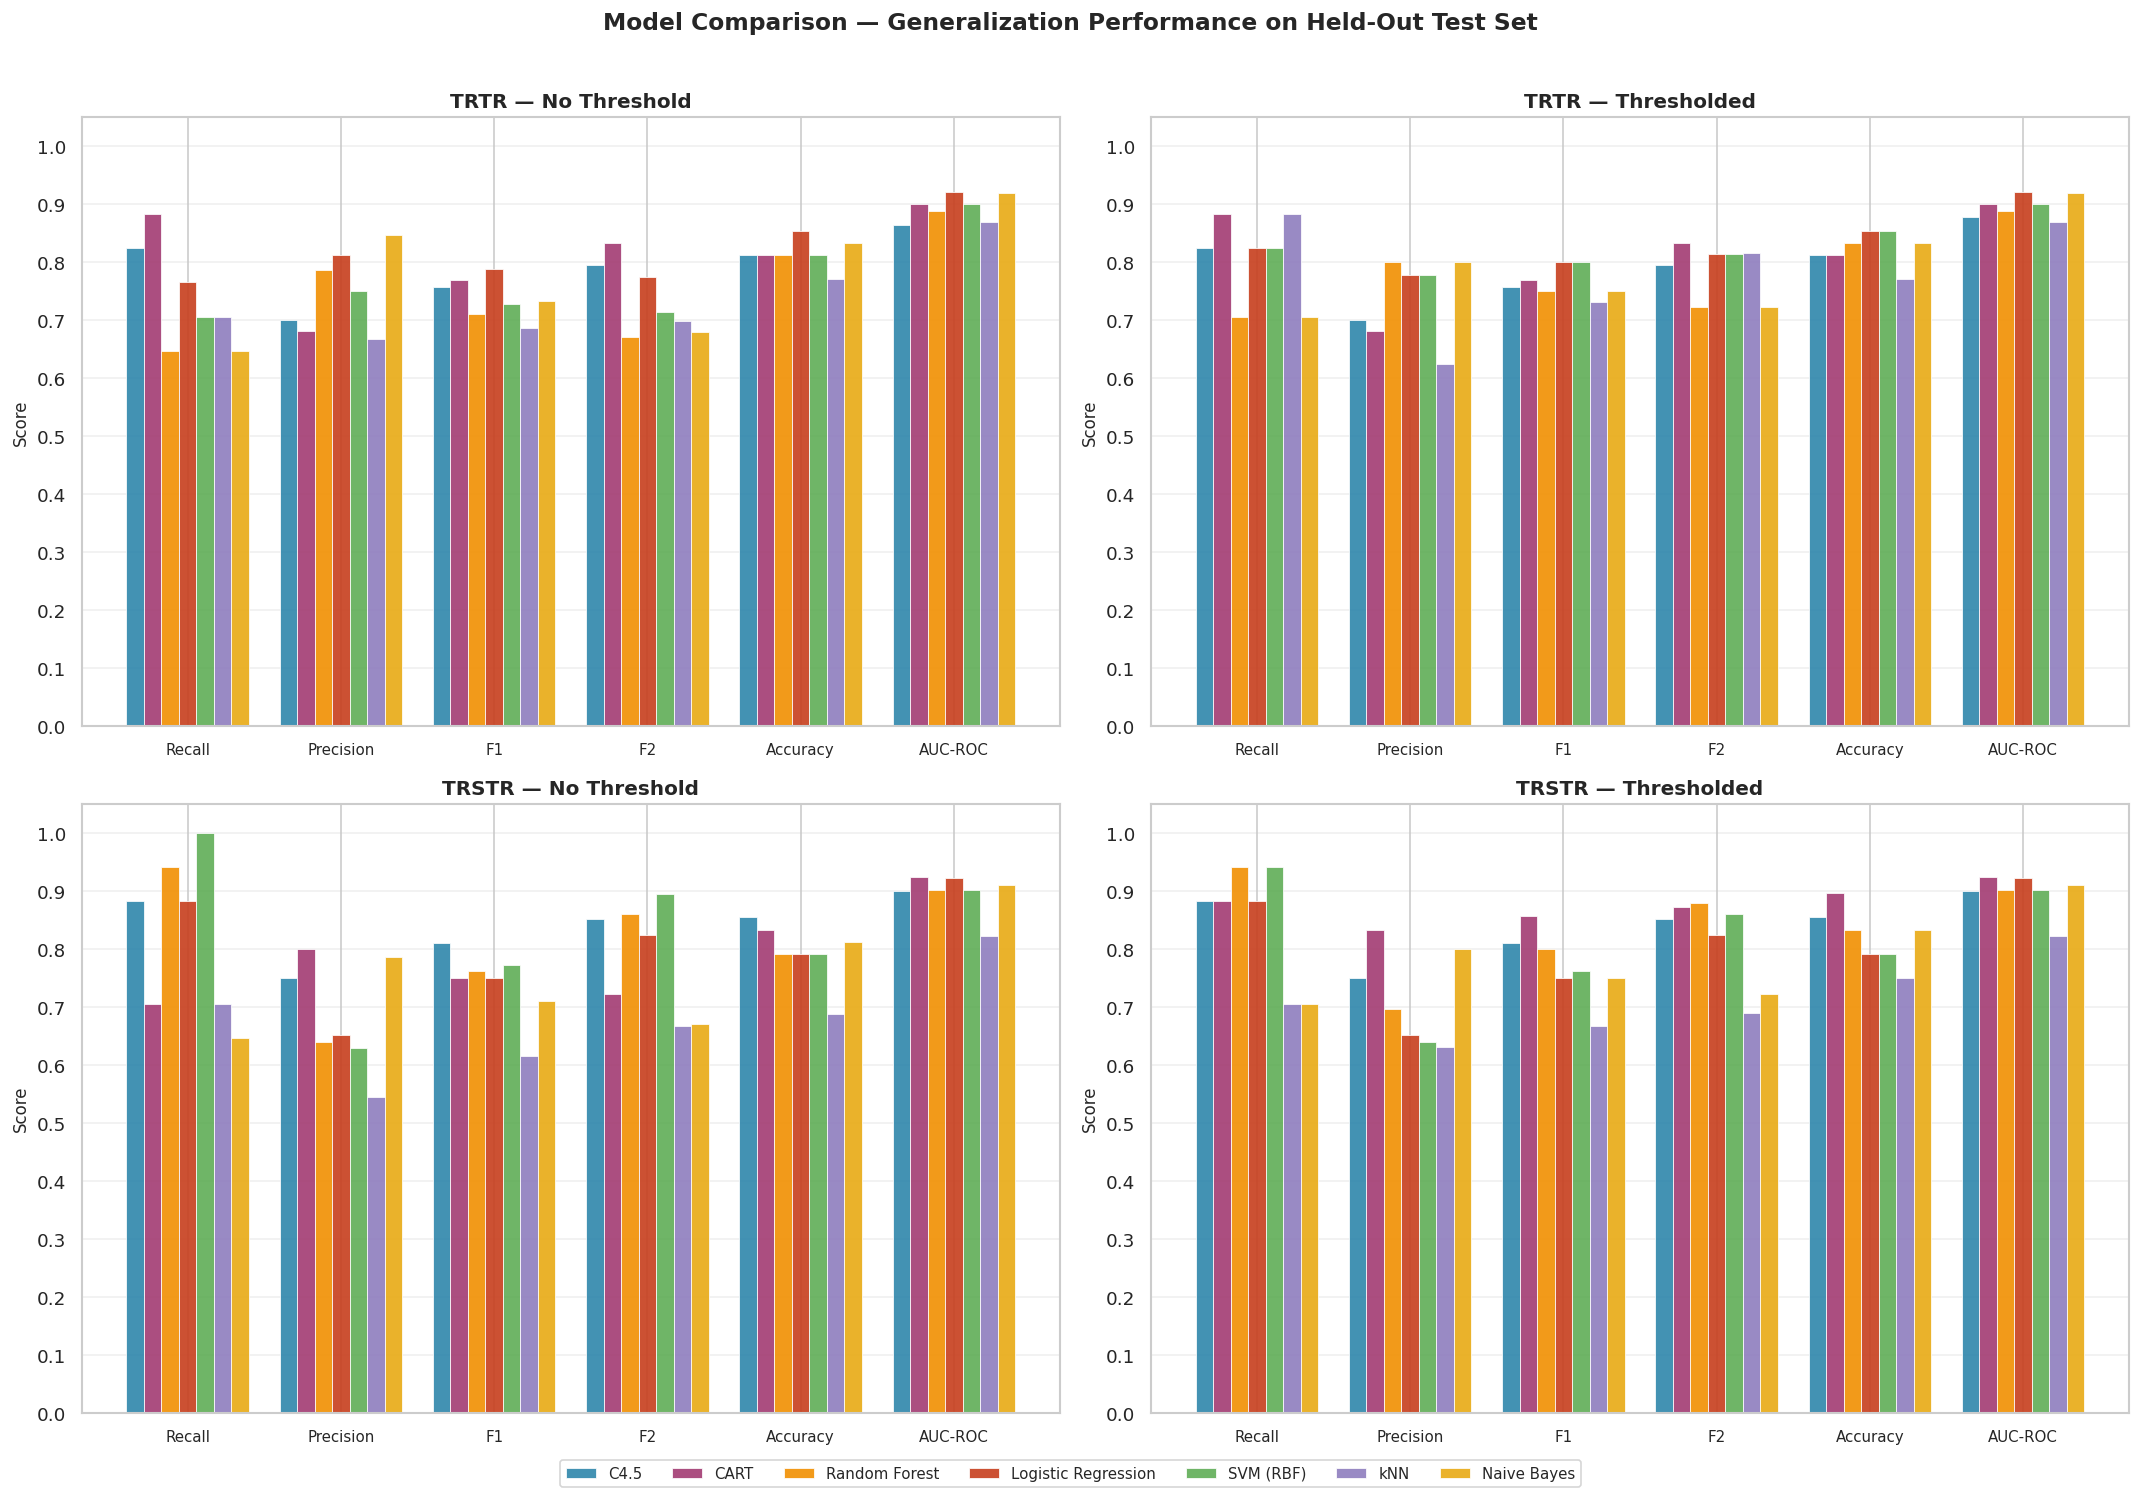

Bar charts saved.


In [9]:
MODEL_COLORS = {
    'C4.5':                 '#2E86AB',
    'CART':                 '#A23B72',
    'Random Forest':        '#F18F01',
    'Logistic Regression':  '#C73E1D',
    'SVM (RBF)':            '#5FAD56',
    'kNN':                  '#8E7DBE',
    'Naive Bayes':          '#E8AA14',
}

DISPLAY_METRICS = ['Recall', 'Precision', 'F1', 'F2', 'Accuracy', 'AUC-ROC']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, cond_key in enumerate(CONDITIONS):
    ax = axes[ax_idx]
    df = results_dfs[cond_key][DISPLAY_METRICS]
    n_models = len(df)
    n_metrics = len(DISPLAY_METRICS)
    x = np.arange(n_metrics)
    bar_width = 0.8 / n_models

    for i, (model_name, row) in enumerate(df.iterrows()):
        offset = (i - n_models / 2 + 0.5) * bar_width
        bars = ax.bar(x + offset, row.values, bar_width,
                      label=model_name, color=MODEL_COLORS[model_name],
                      edgecolor='white', linewidth=0.5, alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(DISPLAY_METRICS, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(CONDITION_LABELS[cond_key], fontweight='bold', fontsize=12)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax.grid(axis='y', alpha=0.3)

# Single legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(MODEL_ORDER),
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Model Comparison — Generalization Performance on Held-Out Test Set',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figures' / 'model_comparison_bar_charts.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Bar charts saved.')

### 6.2 Radar Charts
Per-condition radar plots showing each model's metric profile.

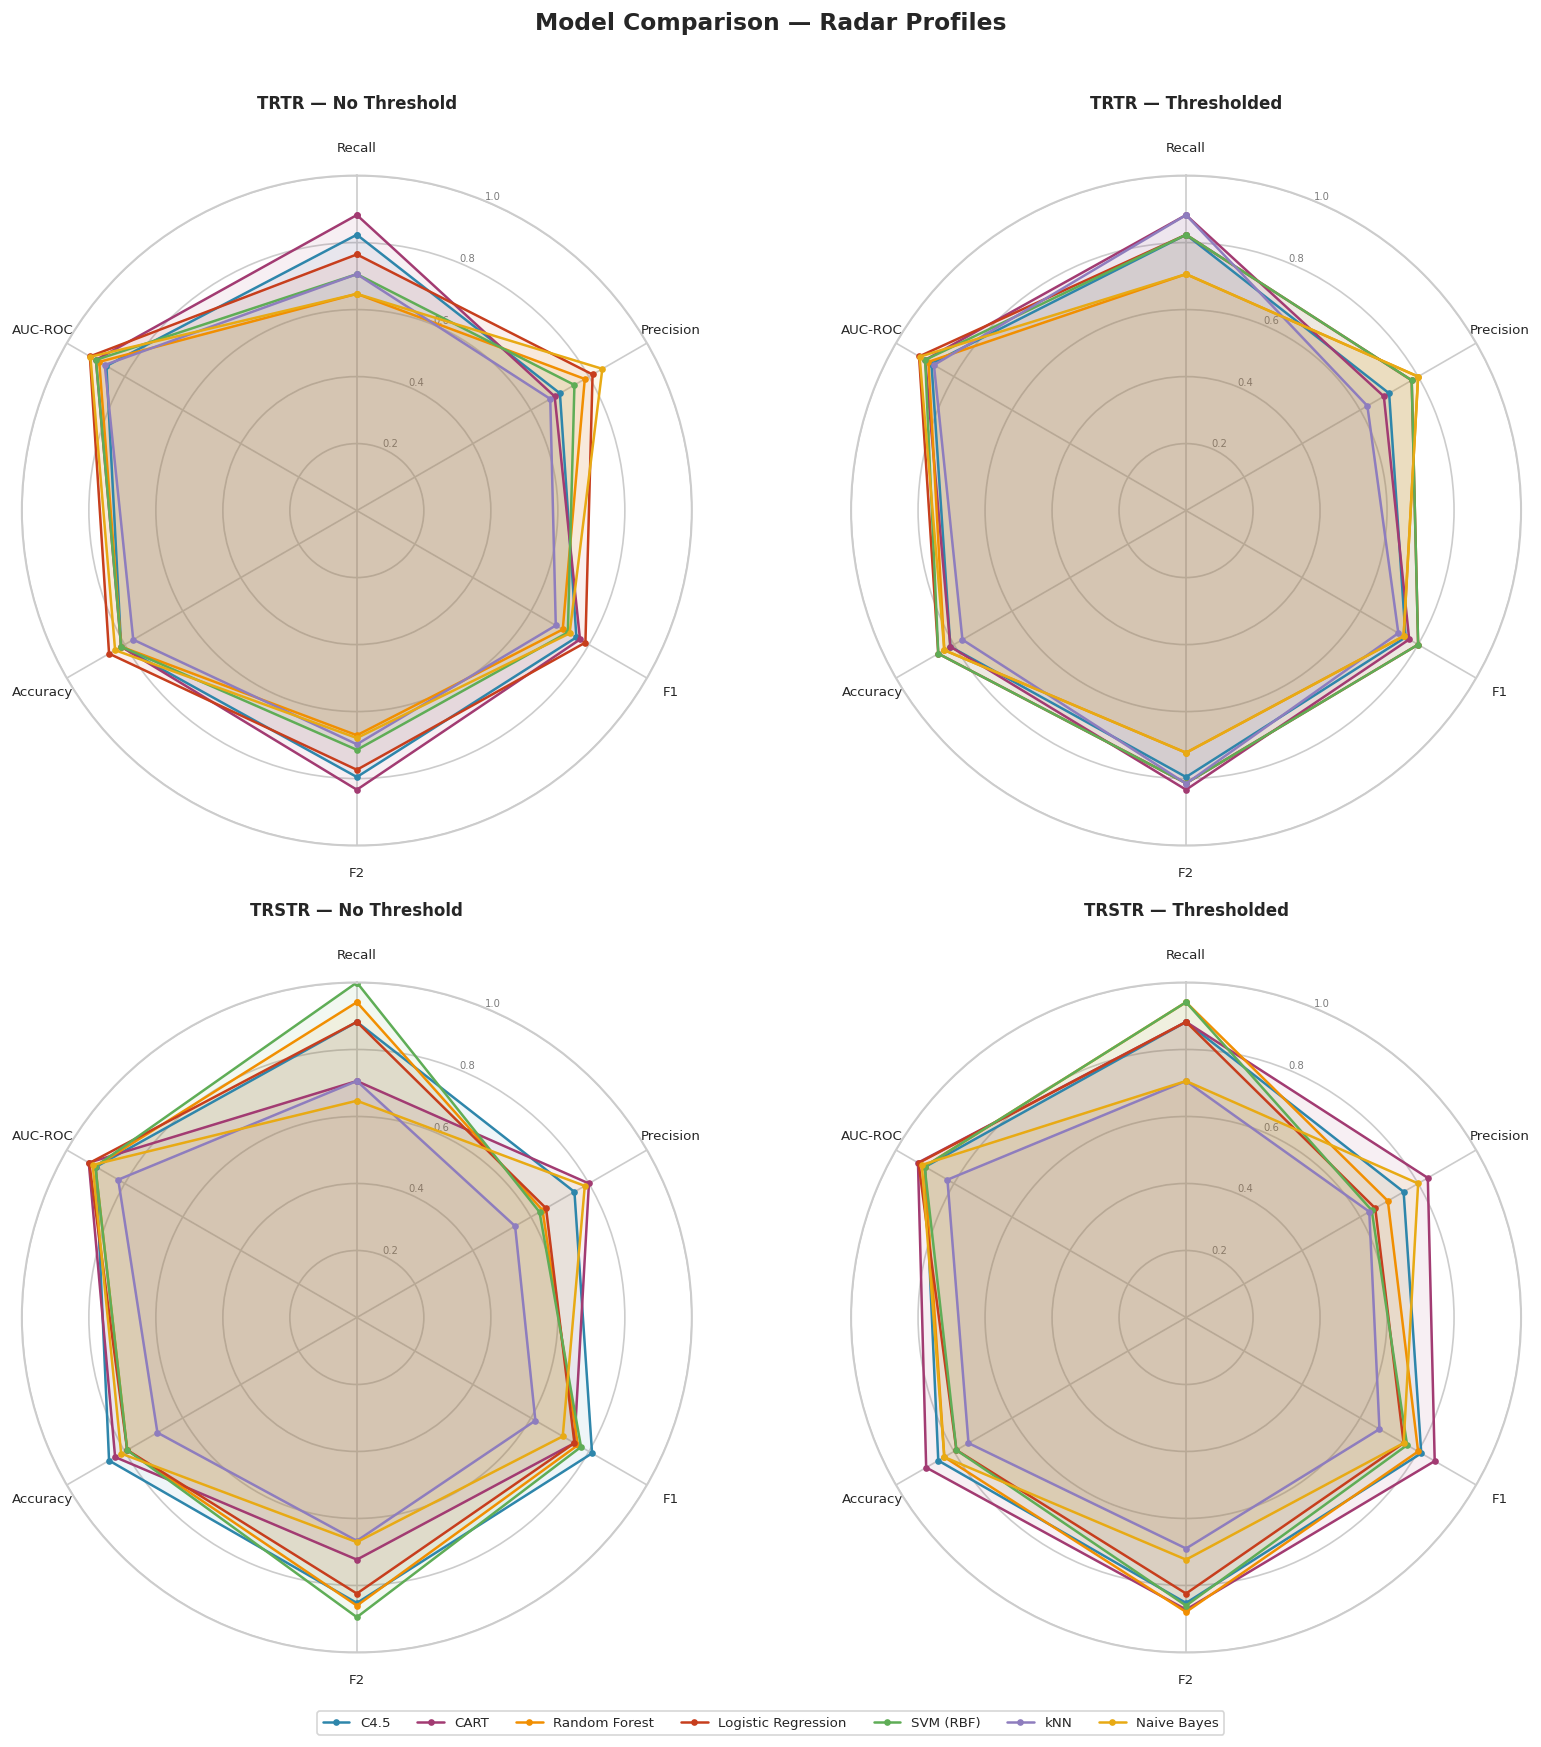

Radar charts saved.


In [10]:
RADAR_METRICS = ['Recall', 'Precision', 'F1', 'F2', 'Accuracy', 'AUC-ROC']

def radar_chart(ax, df, title, colors):
    categories = RADAR_METRICS
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # close the polygon

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=6, alpha=0.6)
    ax.set_title(title, fontweight='bold', fontsize=10, pad=20)

    for model_name, row in df.iterrows():
        values = [row[m] for m in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=1.5, label=model_name,
                color=colors[model_name], markersize=3)
        ax.fill(angles, values, alpha=0.08, color=colors[model_name])

fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax_idx, cond_key in enumerate(CONDITIONS):
    df = results_dfs[cond_key][RADAR_METRICS]
    radar_chart(axes[ax_idx], df, CONDITION_LABELS[cond_key], MODEL_COLORS)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(MODEL_ORDER),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Model Comparison — Radar Profiles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figures' / 'model_comparison_radar_charts.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Radar charts saved.')

### 6.3 Heatmaps
Combined heatmap for each condition — models × metrics.

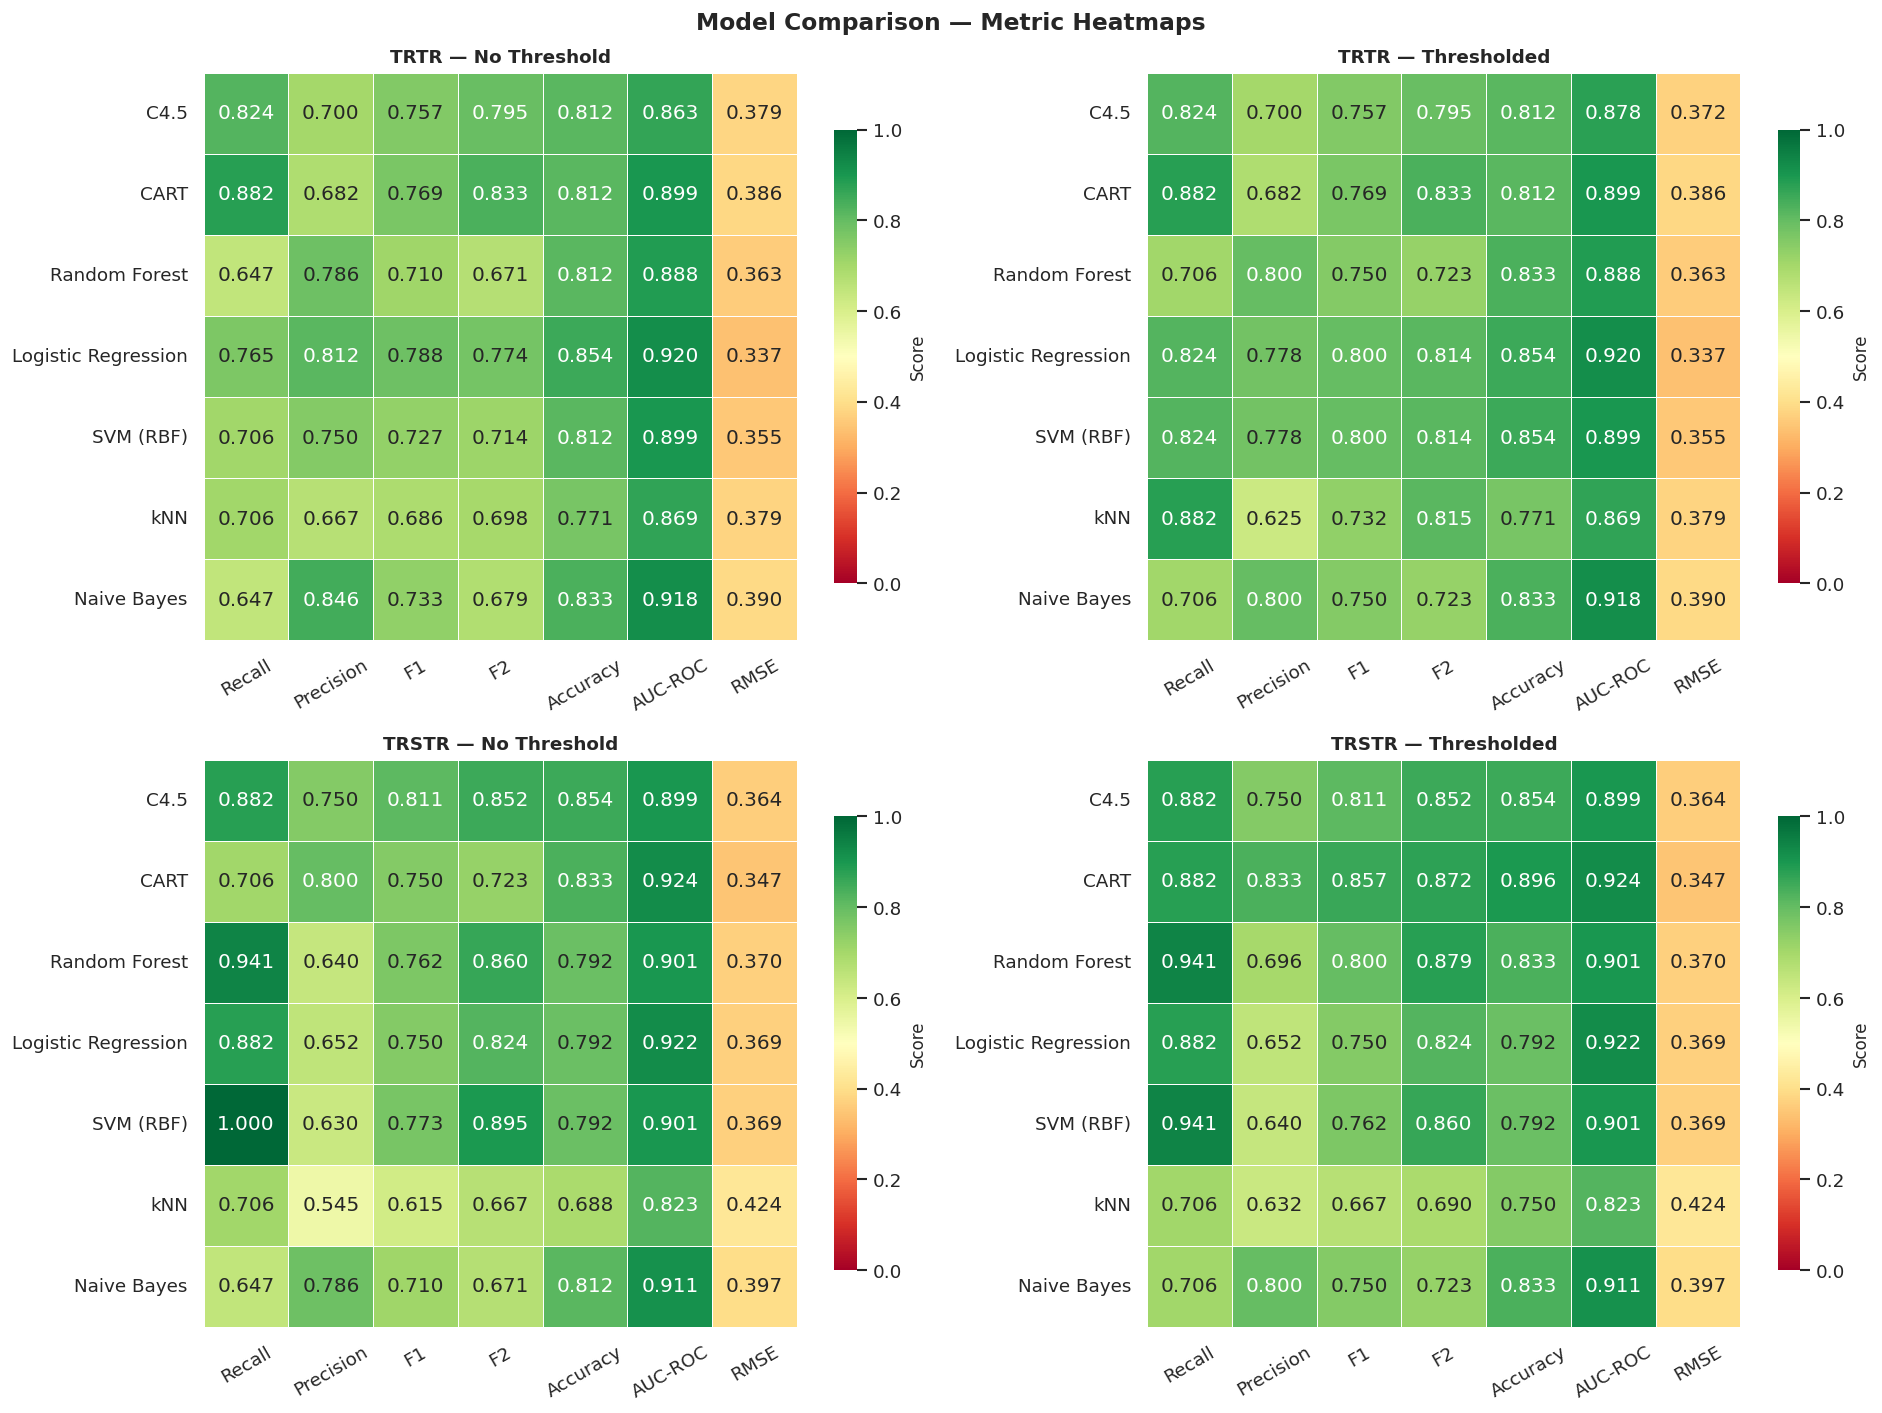

Heatmaps saved.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax_idx, cond_key in enumerate(CONDITIONS):
    ax = axes[ax_idx]
    df = results_dfs[cond_key][METRIC_NAMES].copy()

    # For display: invert RMSE so that heatmap color is consistent (higher = better)
    df_display = df.copy()

    sns.heatmap(df_display, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                linewidths=0.5, linecolor='white',
                vmin=0, vmax=1,
                cbar_kws={'label': 'Score', 'shrink': 0.8})
    ax.set_title(CONDITION_LABELS[cond_key], fontweight='bold', fontsize=11)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Model Comparison — Metric Heatmaps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'figures' / 'model_comparison_heatmaps.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Heatmaps saved.')

## 7. Summary & Export

### C4.5 ranking summary
Shows where C4.5 ranks among all models for each metric in each condition.

### CSV export
Full results exported to `outputs/logs_and_metrics/model_comparison_results.csv`.

In [12]:
print('=' * 70)
print('C4.5 RANKING SUMMARY ACROSS ALL CONDITIONS')
print('=' * 70)

for cond_key in CONDITIONS:
    df = results_dfs[cond_key]
    label = CONDITION_LABELS[cond_key]
    print(f'\n--- {label} ---')
    print(f'{"Metric":>12} {"C4.5 Value":>12} {"Rank":>6} {"Best Model":>22} {"Best Value":>12}')
    print('-' * 68)

    for metric in METRIC_NAMES:
        c45_val = df.loc['C4.5', metric]
        if metric == 'RMSE':
            ranked = df[metric].sort_values(ascending=True)
        else:
            ranked = df[metric].sort_values(ascending=False)
        rank = list(ranked.index).index('C4.5') + 1
        best_model = ranked.index[0]
        best_val = ranked.iloc[0]
        marker = ' ★' if rank == 1 else ''
        print(f'{metric:>12}  {c45_val:>10.4f}  {rank:>4}/7  {best_model:>22}  {best_val:>10.4f}{marker}')

print()

# -- Export all results (test metrics + CIs) to CSV --
export_rows = []
for cond_key, cond_results in all_results.items():
    label, mode = cond_key
    for model_name in MODEL_ORDER:
        if model_name in cond_results:
            test_metrics = cond_results[model_name]
            cis = all_ci_results[cond_key][model_name]
            row = {
                'Training': label,
                'Mode': mode,
                'Model': model_name,
            }
            # Test set metrics + CI bounds
            for metric in METRIC_NAMES:
                row[metric] = test_metrics[metric]
                lo, hi, ci_type = cis[metric]
                row[f'{metric}_CI_Lower'] = lo
                row[f'{metric}_CI_Upper'] = hi
                row[f'{metric}_CI_Type'] = ci_type
            export_rows.append(row)

export_df = pd.DataFrame(export_rows)
export_path = LOGS_OUTPUTS / 'model_comparison_results.csv'
export_df.to_csv(export_path, index=False)
print(f'Results exported to: {export_path}')
print(f'Total rows: {len(export_df)} ({len(MODEL_ORDER)} models x {len(CONDITIONS)} conditions)')
print(f'Columns: test metrics + 95% CI bounds for each metric')

C4.5 RANKING SUMMARY ACROSS ALL CONDITIONS

--- TRTR — No Threshold ---
      Metric   C4.5 Value   Rank             Best Model   Best Value
--------------------------------------------------------------------
      Recall      0.8235     2/7                    CART      0.8824
   Precision      0.7000     5/7             Naive Bayes      0.8462
          F1      0.7568     3/7     Logistic Regression      0.7879
          F2      0.7955     2/7                    CART      0.8333
    Accuracy      0.8125     3/7     Logistic Regression      0.8542
     AUC-ROC      0.8634     7/7     Logistic Regression      0.9203
        RMSE      0.3792     5/7     Logistic Regression      0.3373

--- TRTR — Thresholded ---
      Metric   C4.5 Value   Rank             Best Model   Best Value
--------------------------------------------------------------------
      Recall      0.8235     3/7                    CART      0.8824
   Precision      0.7000     5/7           Random Forest      0.8000
   